On June 5, 2024, Governor Hochul paused the program\. She stopped the new traffic tolls right before they were supposed to start\.

On November 22, 2024, Governor Hochul revived the program\. She announced it would move forward with a reduced toll rate\.

On January 5, 2025, congestion pricing officially went live\. Drivers began paying a fee to enter lower Manhattan\.On January 17, 2025, the federal government attempted to freeze the program\. They tried to halt the tolls and revoke their approval\.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns
import duckdb

In [35]:
from pathlib import Path

EDA_OUTPUT_DIR = Path("eda_outputs")
EDA_OUTPUT_DIR.mkdir(exist_ok=True)

In [9]:
pd.set_option("display.max_columns", None)
plt.rcParams["figure.dpi"] = 120

PIPELINE_DATA_DIR = Path("pipeline_data")

MILESTONES = {
    "Hochul Pause": "2024-06-05",
    "Hochul Unpause": "2024-11-22",
    "CP Implementation": "2025-01-05",
    "Trump Federal Freeze": "2025-01-17",
}
MILESTONE_DATES = {k: pd.Timestamp(v) for k, v in MILESTONES.items()}
CP_START = pd.Timestamp("2025-01-05")

In [27]:
# TLC (FHVHV): weekly trip counts via DuckDB

tlc_dir = PIPELINE_DATA_DIR / "1.2.3.final_tables"

fhvhv_files = sorted(tlc_dir.rglob("fhvhv_tripdata_*_mobility.parquet"))

print("TLC directory:", tlc_dir.resolve())
print("FHVHV files found:", len(fhvhv_files))

if not fhvhv_files:
    raise FileNotFoundError(f"No FHVHV mobility files found under {tlc_dir.resolve()}")

tlc_weekly = duckdb.sql(
    """
    SELECT
        date_trunc('week', CAST(date AS DATE)) AS week,
        SUM(trip_count) AS fhvhv_trips
    FROM read_parquet(?)
    GROUP BY 1
    ORDER BY 1
    """,
    params=([str(f) for f in fhvhv_files],),
).df()

tlc_weekly["week"] = pd.to_datetime(tlc_weekly["week"])

print("TLC weeks:", tlc_weekly.shape)
display(tlc_weekly.head())

TLC directory: /datasets/_deepnote_work/pipeline_data/1.2.3.final_tables
FHVHV files found: 39
TLC weeks: (171, 2)


,week,fhvhv_trips
0,2022-12-26,628913.0
1,2023-01-02,3711712.0
2,2023-01-09,4232799.0
3,2023-01-16,4364200.0
4,2023-01-23,4465688.0


In [25]:
from pathlib import Path

for d in [
    "1.2.3.final_tables",
    "1.2.4.harmonized_mobility_datasets",
    "1.2.4.mobility_integration_tables",
    "1.3.1.final_tables",
]:
    p = PIPELINE_DATA_DIR / d

    print(f"\n=== {d} ===")

    if not p.exists():
        print("directory missing")
        continue

    files = sorted(p.rglob("*.parquet"))

    print("parquet files:", len(files))

    for f in files[:20]:
        print(
            f.name,
            f.stat().st_size // 1024,
            "KB"
        )


=== 1.2.3.final_tables ===
parquet files: 118
fhvhv_tripdata_2023-01_mobility.parquet 73819 KB
fhvhv_tripdata_2023-02_mobility.parquet 69789 KB
fhvhv_tripdata_2023-03_mobility.parquet 85117 KB
fhvhv_tripdata_2023-04_mobility.parquet 78419 KB
fhvhv_tripdata_2023-05_mobility.parquet 85040 KB
fhvhv_tripdata_2023-06_mobility.parquet 82831 KB
fhvhv_tripdata_2023-07_mobility.parquet 78137 KB
fhvhv_tripdata_2023-08_mobility.parquet 75553 KB
fhvhv_tripdata_2023-09_mobility.parquet 82362 KB
fhvhv_tripdata_2023-10_mobility.parquet 84186 KB
fhvhv_tripdata_2023-11_mobility.parquet 80508 KB
fhvhv_tripdata_2023-12_mobility.parquet 84725 KB
fhvhv_tripdata_2024-01_mobility.parquet 75704 KB
fhvhv_tripdata_2024-02_mobility.parquet 79406 KB
fhvhv_tripdata_2024-03_mobility.parquet 86206 KB
fhvhv_tripdata_2024-04_mobility.parquet 81807 KB
fhvhv_tripdata_2024-05_mobility.parquet 85707 KB
fhvhv_tripdata_2024-06_mobility.parquet 84013 KB
fhvhv_tripdata_2024-07_mobility.parquet 77004 KB
fhvhv_tripdata_2024-08

In [29]:
# Traffic: weekly volume

traffic = pd.read_parquet(
    PIPELINE_DATA_DIR / "1.2.1.traffic_counts_temporal.parquet"
)

traffic["week"] = (
    pd.to_datetime(traffic["date"], errors="coerce")
    .dt.to_period("W")
    .dt.start_time
)

traffic_weekly = (
    traffic.dropna(subset=["week"])
    .groupby("week")["traffic_volume"]
    .sum()
    .reset_index()
    .rename(columns={"traffic_volume": "traffic_volume_sum"})
)


# Bridge/Tunnel: weekly crossings

bt = pd.read_parquet(
    PIPELINE_DATA_DIR / "1.2.1.bridge_tunnel_temporal.parquet"
)

date_col = [
    c for c in bt.columns
    if "date" in c.lower() or "timestamp" in c.lower()
][0]

vol_col = [
    c for c in bt.columns
    if "crossing" in c.lower()
    or "volume" in c.lower()
    or "count" in c.lower()
][0]

bt["week"] = (
    pd.to_datetime(bt[date_col], errors="coerce")
    .dt.to_period("W")
    .dt.start_time
)

bt_weekly = (
    bt.dropna(subset=["week"])
    .groupby("week")[vol_col]
    .sum()
    .reset_index()
)

bt_weekly.columns = ["week", "bt_crossings"]

# ---------------------------------------------------------------
# TLC FHVHV: weekly trip counts from updated final tables
# ---------------------------------------------------------------
tlc_dir = PIPELINE_DATA_DIR / "1.2.3.final_tables"
fhvhv_files = sorted(tlc_dir.rglob("fhvhv_tripdata_*_mobility.parquet"))

print("FHVHV files found:", len(fhvhv_files))

tlc_weekly = duckdb.sql(
    """
    SELECT
        date_trunc('week', CAST(date AS DATE)) AS week,
        SUM(trip_count) AS fhvhv_trips
    FROM read_parquet(?)
    GROUP BY 1
    ORDER BY 1
    """,
    params=([str(f) for f in fhvhv_files],),
).df()

tlc_weekly["week"] = pd.to_datetime(tlc_weekly["week"])

print("Traffic weeks:", traffic_weekly.shape)
print("Bridge/Tunnel weeks:", bt_weekly.shape)
print("TLC weeks:", tlc_weekly.shape)

FHVHV files found: 39
Traffic weeks: (125, 2)
Bridge/Tunnel weeks: (177, 2)
TLC weeks: (171, 2)


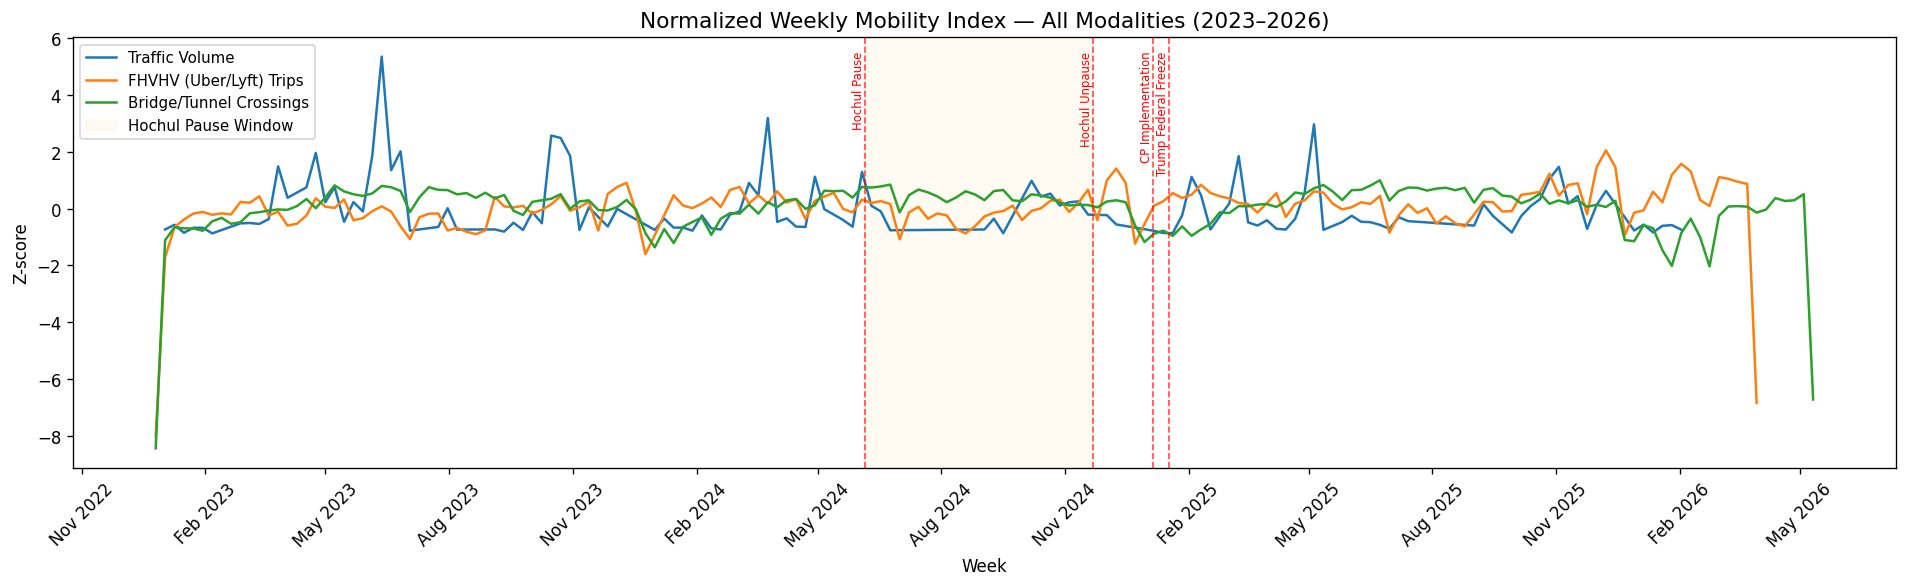

In [37]:
# Normalized weekly mobility index

def normalize(series):
    return (series - series.mean()) / series.std()

fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(
    traffic_weekly["week"],
    normalize(traffic_weekly["traffic_volume_sum"]),
    label="Traffic Volume",
    linewidth=1.5,
    color="#1f77b4",
)

ax.plot(
    tlc_weekly["week"],
    normalize(tlc_weekly["fhvhv_trips"]),
    label="FHVHV (Uber/Lyft) Trips",
    linewidth=1.5,
    color="#ff7f0e",
)

ax.plot(
    bt_weekly["week"],
    normalize(bt_weekly["bt_crossings"]),
    label="Bridge/Tunnel Crossings",
    linewidth=1.5,
    color="#2ca02c",
)

for label, date in MILESTONE_DATES.items():
    ax.axvline(date, color="red", linestyle="--", linewidth=1, alpha=0.7)
    ax.text(
        date,
        ax.get_ylim()[1] * 0.92,
        label,
        rotation=90,
        fontsize=7,
        color="red",
        va="top",
        ha="right",
    )

ax.axvspan(
    pd.Timestamp("2024-06-05"),
    pd.Timestamp("2024-11-22"),
    alpha=0.05,
    color="orange",
    label="Hochul Pause Window",
)

ax.set_title("Normalized Weekly Mobility Index — All Modalities (2023–2026)", fontsize=13)
ax.set_xlabel("Week")
ax.set_ylabel("Z-score")
ax.legend(loc="upper left", fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(
    "eda_outputs/1_3_1_normalized_mobility_index.png",
    bbox_inches="tight"
)
plt.show()

## Anomaly Detection 

In [39]:

# Weekly anomaly score for Reddit cross-reference

ROLLING_WINDOW = 8
THRESHOLD = 1.5

def rolling_zscore(series, window=8):
    roll_mean = series.rolling(window, center=True, min_periods=4).mean()
    roll_std = series.rolling(window, center=True, min_periods=4).std()
    return (series - roll_mean) / roll_std.replace(0, np.nan)

traffic_weekly["zscore"] = rolling_zscore(traffic_weekly["traffic_volume_sum"])
tlc_weekly["zscore"] = rolling_zscore(tlc_weekly["fhvhv_trips"])
bt_weekly["zscore"] = rolling_zscore(bt_weekly["bt_crossings"])

anomaly_df = traffic_weekly[["week", "zscore"]].rename(columns={"zscore": "z_traffic"})

anomaly_df = anomaly_df.merge(
    tlc_weekly[["week", "zscore"]].rename(columns={"zscore": "z_fhvhv"}),
    on="week",
    how="outer",
)

anomaly_df = anomaly_df.merge(
    bt_weekly[["week", "zscore"]].rename(columns={"zscore": "z_bridge_tunnel"}),
    on="week",
    how="outer",
)

anomaly_df["anomaly_score"] = (
    (anomaly_df["z_traffic"].abs() > THRESHOLD).astype(int)
    + (anomaly_df["z_fhvhv"].abs() > THRESHOLD).astype(int)
    + (anomaly_df["z_bridge_tunnel"].abs() > THRESHOLD).astype(int)
)

top_anomaly_weeks = (
    anomaly_df[anomaly_df["anomaly_score"] > 0]
    .sort_values(["anomaly_score", "week"], ascending=[False, True])
    .head(20)
)

print("Top candidate weeks for Reddit cross-reference:")
display(top_anomaly_weeks)

top_anomaly_weeks.to_csv(EDA_OUTPUT_DIR / "candidate_reddit_dates.csv", index=False)

Top candidate weeks for Reddit cross-reference:


,week,z_traffic,z_fhvhv,z_bridge_tunnel,anomaly_score
102,2025-06-30,-1.534288,-2.081039,-1.997359,3
23,2023-07-03,-0.874499,-2.068655,-2.224672,2
138,2024-07-01,NaN,-2.174108,-2.289711,2
5,2023-02-06,-1.518903,-0.027938,0.836775,1
13,2023-04-24,1.629630,1.271974,-0.807707,1
15,2023-05-08,0.397132,0.343788,1.587361,1
20,2023-06-12,2.095821,0.825049,0.989399,1
30,2023-09-25,-0.482913,0.364896,-1.759629,1
34,2023-10-23,1.297750,1.797762,1.297976,1
134,2023-11-20,NaN,-1.933538,-1.025923,1


In [43]:
import geopandas as gpd
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

In [47]:
taxi_zones = gpd.read_parquet(
    PIPELINE_DATA_DIR / "1.1.6.nyc_taxi_zones.parquet"
)

In [51]:
# FHVHV zone-level pre/post CP choropleth

tlc_zone = duckdb.sql(
    """
    SELECT
        pickup_zone_id AS location_id,
        CASE
            WHEN CAST(date AS DATE) < DATE '2025-01-05'
            THEN 'pre'
            ELSE 'post'
        END AS period,
        SUM(trip_count) AS trips
    FROM read_parquet(?)
    WHERE YEAR(CAST(date AS DATE)) >= 2024
    GROUP BY 1, 2
    """,
    params=([str(f) for f in fhvhv_files],),
).df()

tlc_pivot = (
    tlc_zone
    .pivot_table(index="location_id", columns="period", values="trips", aggfunc="sum")
    .reset_index()
)

tlc_pivot = tlc_pivot.rename(columns={
    "pre": "pre_trips",
    "post": "post_trips",
})

for col in ["pre_trips", "post_trips"]:
    if col not in tlc_pivot.columns:
        tlc_pivot[col] = np.nan

tlc_pivot["pct_change"] = (
    (tlc_pivot["post_trips"] - tlc_pivot["pre_trips"])
    / tlc_pivot["pre_trips"]
    * 100
)

zones_merged = taxi_zones.merge(tlc_pivot, on="location_id", how="left")

print(zones_merged.shape)
display(zones_merged.head())

(263, 9)


,location_id,zone,borough,shape_length,shape_area,geometry,post_trips,pre_trips,pct_change
0,1,Newark Airport,EWR,0.116357,0.000782,"MULTIPOLYGON (((-74.18445 40.695, -74.18449 40...",17.0,17.0,0.000000
1,2,Jamaica Bay,Queens,0.433470,0.004866,"MULTIPOLYGON (((-73.82338 40.63899, -73.82277 ...",774.0,531.0,45.762712
2,3,Allerton/Pelham Gardens,Bronx,0.084341,0.000314,"MULTIPOLYGON (((-73.84793 40.87134, -73.84725 ...",704259.0,527840.0,33.422818
3,4,Alphabet City,Manhattan,0.043567,0.000112,"MULTIPOLYGON (((-73.97177 40.72582, -73.97179 ...",835735.0,757189.0,10.373368
4,5,Arden Heights,Staten Island,0.092146,0.000498,"MULTIPOLYGON (((-74.17422 40.56257, -74.17349 ...",89899.0,71620.0,25.522201


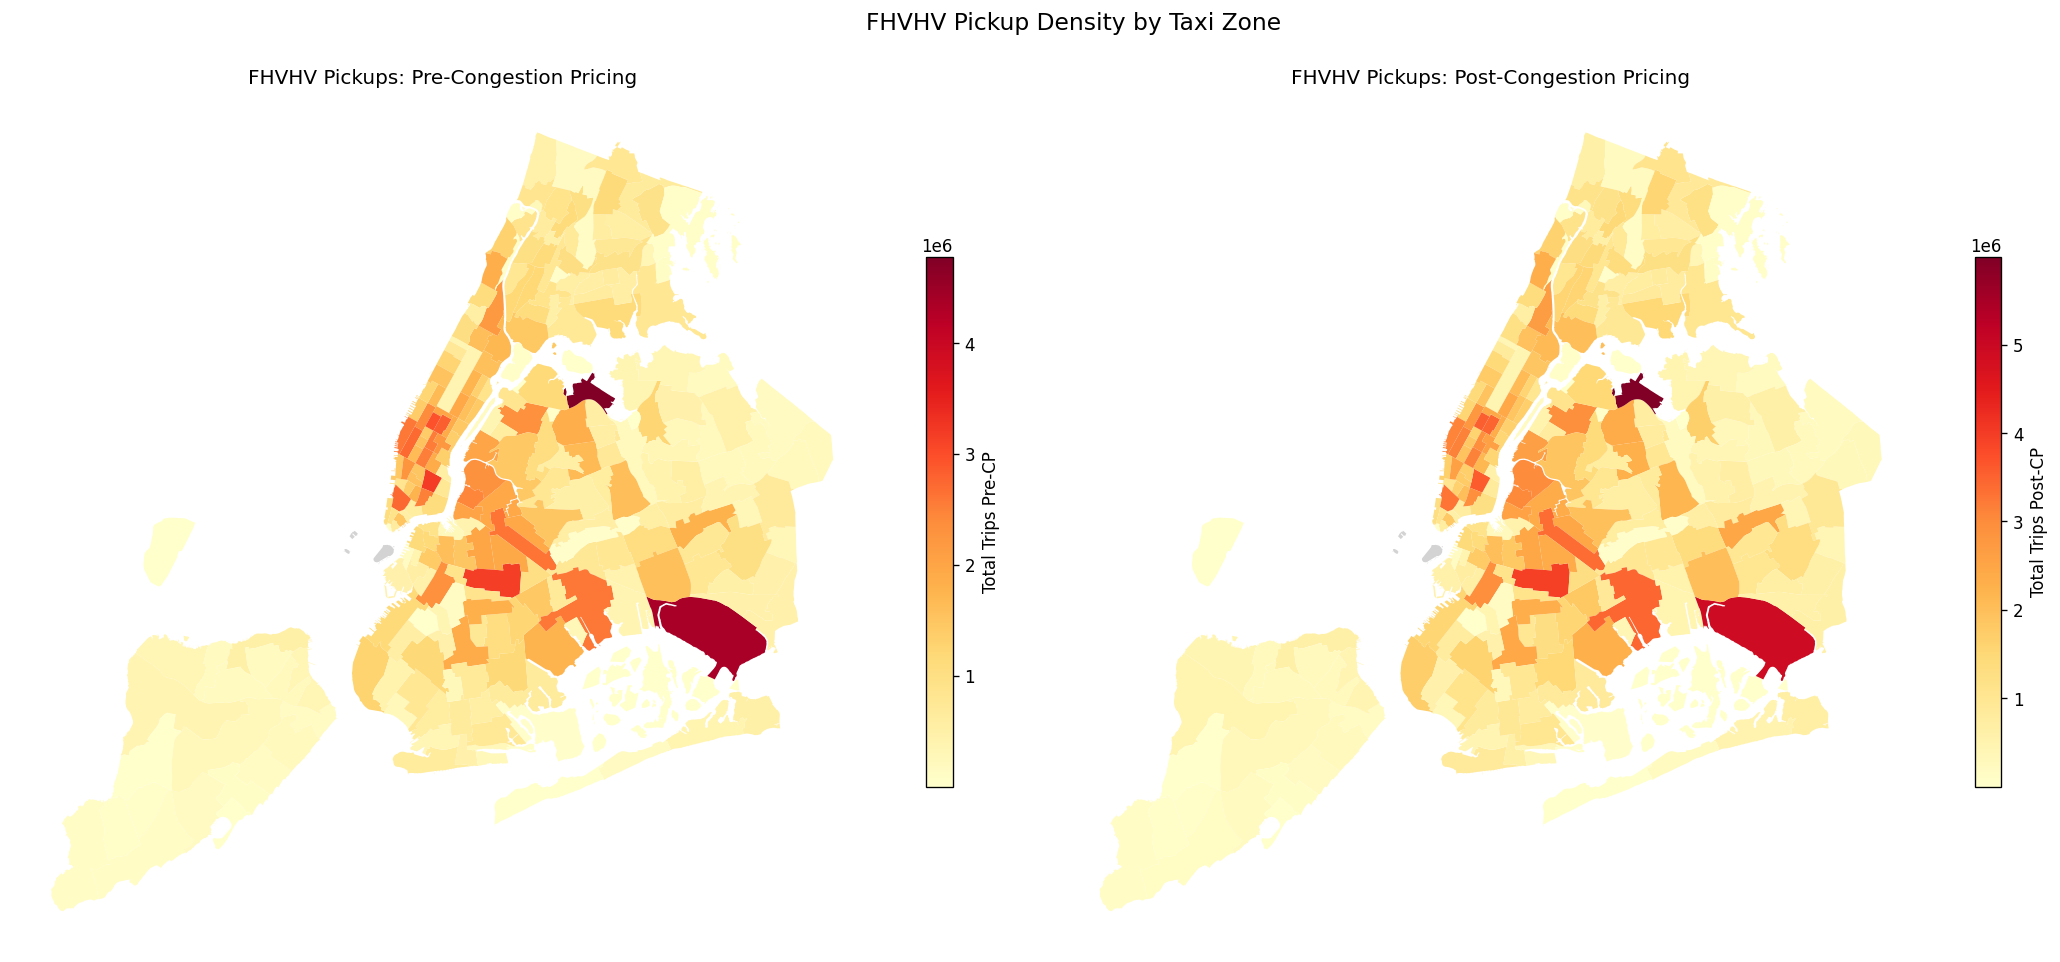

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

zones_merged.plot(
    column="pre_trips",
    ax=axes[0],
    cmap="YlOrRd",
    legend=True,
    missing_kwds={"color": "lightgrey"},
    legend_kwds={"label": "Total Trips Pre-CP", "shrink": 0.6},
)

axes[0].set_title("FHVHV Pickups: Pre-Congestion Pricing", fontsize=12)
axes[0].axis("off")

zones_merged.plot(
    column="post_trips",
    ax=axes[1],
    cmap="YlOrRd",
    legend=True,
    missing_kwds={"color": "lightgrey"},
    legend_kwds={"label": "Total Trips Post-CP", "shrink": 0.6},
)

axes[1].set_title("FHVHV Pickups: Post-Congestion Pricing", fontsize=12)
axes[1].axis("off")

plt.suptitle("FHVHV Pickup Density by Taxi Zone", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(EDA_OUTPUT_DIR / "1_3_2_fhvhv_pre_post_choropleth.png", bbox_inches="tight")
plt.show()

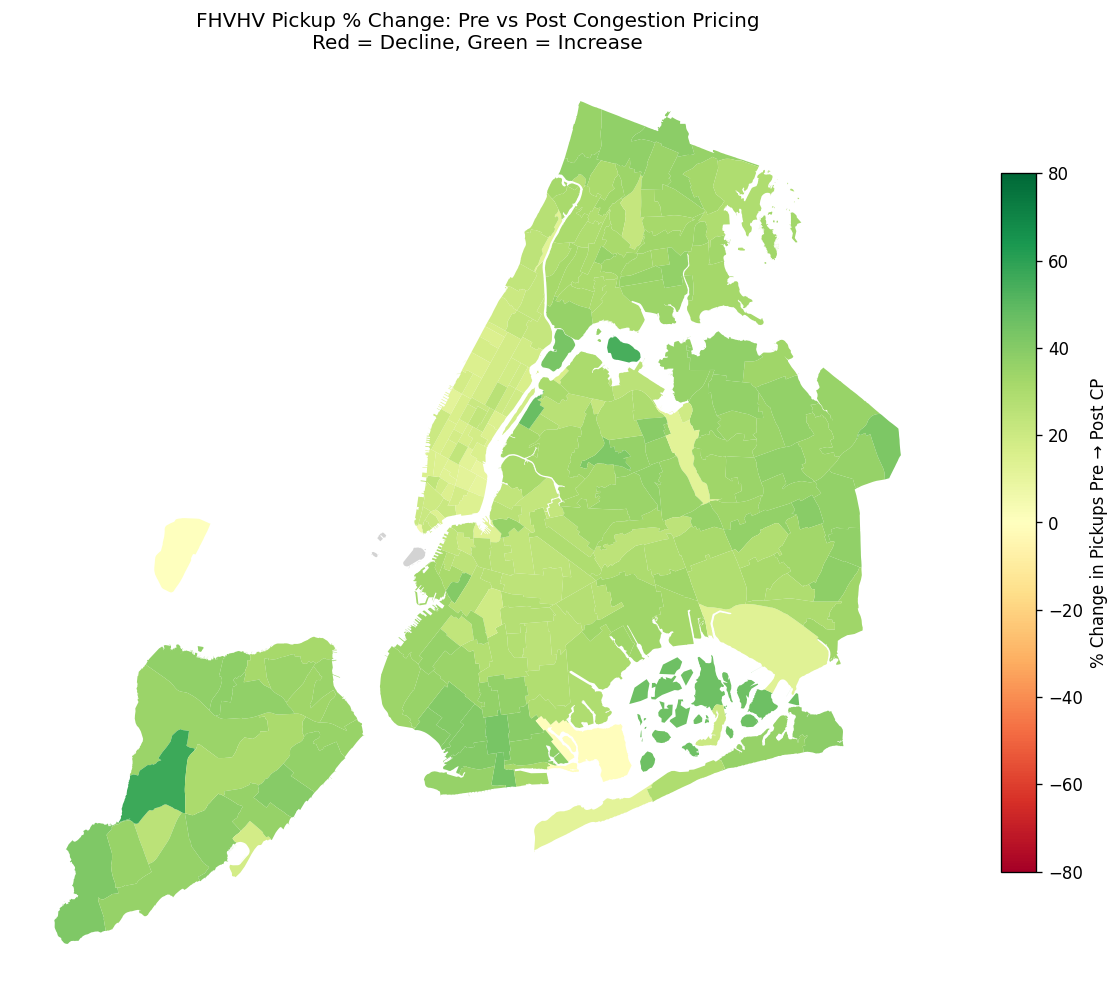


Top 10 Taxi Zones by trip decline:


,zone,borough,pct_change
153,Marine Park/Floyd Bennett Field,Brooklyn,-0.626654
0,Newark Airport,EWR,0.000000
11,Battery Park,Manhattan,6.013290
223,Stuy Town/Peter Cooper Village,Manhattan,9.921429
3,Alphabet City,Manhattan,10.373368
49,Clinton West,Manhattan,11.486262
26,Breezy Point/Fort Tilden/Riis Beach,Queens,11.631145
78,East Village,Manhattan,11.852368
119,Highbridge Park,Manhattan,12.133874
92,Flushing Meadows-Corona Park,Queens,12.278922



Top 10 Taxi Zones by trip gain:


,zone,borough,pct_change
98,Freshkills Park,Staten Island,56.505223
198,Rikers Island,Bronx,53.968254
192,Queensbridge/Ravenswood,Queens,47.039151
1,Jamaica Bay,Queens,45.762712
28,Brighton Beach,Brooklyn,44.163100
122,Homecrest,Brooklyn,43.571272
193,Randalls Island,Manhattan,43.128467
100,Glen Oaks,Queens,42.284005
43,Charleston/Tottenville,Staten Island,41.817903
82,Elmhurst/Maspeth,Queens,41.401993


In [55]:
fig, ax = plt.subplots(figsize=(10, 10))

divnorm = mcolors.TwoSlopeNorm(vmin=-80, vcenter=0, vmax=80)

zones_merged.plot(
    column="pct_change",
    ax=ax,
    cmap="RdYlGn",
    norm=divnorm,
    legend=True,
    missing_kwds={"color": "lightgrey", "label": "No data"},
    legend_kwds={
        "label": "% Change in Pickups Pre → Post CP",
        "shrink": 0.6,
    },
)

ax.set_title(
    "FHVHV Pickup % Change: Pre vs Post Congestion Pricing\n"
    "Red = Decline, Green = Increase",
    fontsize=12,
)

ax.axis("off")
plt.tight_layout()
plt.savefig(EDA_OUTPUT_DIR / "1_3_2_fhvhv_pct_change_choropleth.png", bbox_inches="tight")
plt.show()

print("\nTop 10 Taxi Zones by trip decline:")
display(
    zones_merged[["zone", "borough", "pct_change"]]
    .dropna()
    .sort_values("pct_change")
    .head(10)
)

print("\nTop 10 Taxi Zones by trip gain:")
display(
    zones_merged[["zone", "borough", "pct_change"]]
    .dropna()
    .sort_values("pct_change", ascending=False)
    .head(10)
)

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=4a322346-8e1e-4650-8cef-fe9b767d96fb' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>